In [3]:
import sys
from pathlib import Path

# Path to the parent folder (where util is)
parent_path = Path().resolve().parent.parent
sys.path.append(str(parent_path))
import util
import plotting.plotting_style as plt
import pandas as pd
import numpy as np
#import matplotlib.pyplot as plt
import seaborn as sns
import help_functions as hp
#import tueplots as tue

data = util.load_data(path_file='C:\\Users\\Mattis\\OneDrive\\Kogni\\DataLiteracyProject\\Data-Literacy\\data_csv\\final_data_iaaf_scores_neu.csv') 

data.head()

,jahr,geschlecht,altersklasse,disziplin,leistung,wind,name,geburtsjahr,verein,datum,ort,iaaf_score
0,2017,W,Frauen,100 m,10.95,"+1,3",Gina Lueckenkemper,1996,LG Olympia Dortmund,05.08.,London/GBR,1211
1,2017,W,Frauen,100 m,11.06,"+1,8",Rebekka Haase,1993,LV 90 Erzgebirge,25.05.,Zeulenroda,1187
2,2017,W,Frauen,100 m,11.14,"-0,2",Lisa Mayer,1996,Sprintteam Wetzlar,27.08.,Berlin,1169
3,2017,W,Frauen,100 m,11.24,"+0,3",Tatjana Pinto,1992,LC Paderborn,15.07.,Ninove/BEL,1148
4,2017,W,Frauen,100 m,11.25,"+1,9",Sina Mayer,1995,LAZ Zweibruecken,11.06.,Regensburg,1146


In [4]:
#Define Adult age group
data['altersklasse'] = data['altersklasse'].replace({'Maenner': 'Adult', 'Frauen': 'Adult', '16': 'U16', '18': 'U18', '20': 'U20', '14': 'AK14'})

# Nur die relevanten Altersklassen behalten
target_ak = ['Adult', 'U23', 'U20', 'U18']
data = data[data['altersklasse'].isin(target_ak)]

In [5]:
allowed_disciplines = {
    'U18': [
        '100 m', '200 m', '400 m', '100 m Huerden', '110 m Huerden', '400m Huerden',
        '800 m', '1500 m', '3000 m', '2000 m Hindernis',
        'Kugelstoss', 'Diskuswurf', 'Speerwurf', 'Hammerwurf',
        'Hochsprung', 'Stabhochsprung', 'Weitsprung', 'Dreisprung',
        'Zehnkampf', 'Siebenkampf'
    ],
    'U20': [
        '100 m', '200 m', '400 m', '100 m Huerden', '110 m Huerden', '400m Huerden',
        '800 m', '1500 m', '3000 m', '5000 m', '3000 m Hindernis',
        'Kugelstoss', 'Diskuswurf', 'Speerwurf', 'Hammerwurf',
        'Hochsprung', 'Stabhochsprung', 'Weitsprung', 'Dreisprung',
        'Zehnkampf', 'Siebenkampf'
    ],
    'U23': [
        '100 m', '200 m', '400 m', '100 m Huerden', '110 m Huerden', '400 m Huerden',
        '800 m', '1500 m', '5000 m' '10 km', '3000 m Hindernis',
        'Kugelstoss', 'Diskuswurf', 'Speerwurf', 'Hammerwurf',
        'Hochsprung', 'Stabhochsprung', 'Weitsprung', 'Dreisprung',
        'Zehnkampf', 'Siebenkampf'
    ],
    'Adult': [
        '100 m', '200 m', '400 m', '100 m Huerden', '110 m Huerden', '400 m Huerden',
        '800 m', '1500 m', '5000 m' '10 km', '3000 m Hindernis', 'Marathon',
        'Kugelstoss', 'Diskuswurf', 'Speerwurf', 'Hammerwurf',
        'Hochsprung', 'Stabhochsprung', 'Weitsprung', 'Dreisprung',
        'Zehnkampf', 'Siebenkampf'
    ]
}

def check_discipline(row):
    ak = row['altersklasse']
    disz = row['disziplin']
    
    # Prüfen, ob die AK im Dictionary existiert und ob die Disziplin darin erlaubt ist
    if ak in allowed_disciplines:
        return disz in allowed_disciplines[ak]
    return False

# Filter anwenden
data = data[data.apply(check_discipline, axis=1)]


In [6]:
# --- Find entries with less than 40 data points per year, age group, gender, and discipline ---

summary = data.groupby(['jahr', 'altersklasse', 'geschlecht', 'disziplin']).size().reset_index(name='anzahl')


# Exclude all data with 35 or less entries and u23 data -> too less data points
under_35 = summary[(summary['altersklasse'] == 'U23') | (summary['anzahl'] < 35)]

# 3. Sortieren für eine saubere Übersicht
under_35 = under_35.sort_values(by=['jahr', 'altersklasse', 'geschlecht', 'disziplin'])

# 4. Print-Ausgabe
if under_35.empty:
    print("In allen Kategorien sind 40 oder mehr Einträge vorhanden.")
else:
    print("Categories with less than 35 Entries are excluded:")
    print(under_35.to_string(index=False))

data_all = data.groupby(['jahr', 'altersklasse', 'geschlecht', 'disziplin']).filter(lambda x: x.name[1] != 'U23' and len(x) >= 35)

Categories with less than 35 Entries are excluded:
 jahr altersklasse geschlecht        disziplin  anzahl
 2001        Adult          W 3000 m Hindernis      10
 2001          U18          W    100 m Huerden      34
 2001          U23          M            100 m      28
 2001          U23          M    110 m Huerden      20
 2001          U23          M           1500 m      29
 2001          U23          M            200 m      26
 2001          U23          M 3000 m Hindernis      29
 2001          U23          M            400 m      29
 2001          U23          M    400 m Huerden      30
 2001          U23          M            800 m      27
 2001          U23          M       Diskuswurf      30
 2001          U23          M       Dreisprung      31
 2001          U23          M       Hammerwurf      30
 2001          U23          M       Hochsprung      31
 2001          U23          M       Kugelstoss      30
 2001          U23          M        Speerwurf      29
 2001         

In [7]:
data_all = data_all.sort_values(by='iaaf_score', ascending=False) # Sicherstellen, dass die Besten oben stehen
data_all = data_all.groupby(['jahr', 'altersklasse', 'geschlecht', 'disziplin']).head(35)

In [8]:
# Define Discipline groups NOTE: Only the ones with clear data

mapping_dict = {
    **{d: 'Run' for d in ['800 m', '1500 m', '3000 m', '5000 m', '10 km', 'Marathon', '2000 m Hindernis', '3000 m Hindernis']},
    **{d: 'Sprint' for d in ['100 m', '200 m', '400 m', '100 m  Huerden', '110 m Huerden', '400 m Huerden']},
    **{d: 'Throw' for d in ['Kugelstoss', 'Diskuswurf', 'Speerwurf', 'Hammerwurf']}, 
    **{d: 'Jump' for d in ['Hochsprung', 'Stabhochsprung', 'Weitsprung', 'Dreisprung']},
    **{d: 'Combined' for d in ['Zehnkampf', 'Siebenkampf']}
}

data_all['disziplingruppe'] = data_all['disziplin'].map(mapping_dict)

data_all = data_all.sort_values(["jahr", "disziplin", "geschlecht", "altersklasse", "iaaf_score"], ascending=[True, True, True, True, False])

data_all['rank'] = data_all.groupby(["jahr", "disziplin", "geschlecht", "altersklasse"])["iaaf_score"].rank(ascending=False, method='first')

In [9]:

# --- ANWENDUNG ---

# 1. Vorbereitung (wie gehabt)
age_groups = ["U18", "U20", "Adult"]
data_filtered = data_all[data_all["altersklasse"].isin(age_groups)].copy()

# 2. Aufruf für die verschiedenen Granularitäten
results_ranks_disc_age = hp.calculate_rank_diff(data_filtered, ["disziplingruppe", "geschlecht", "altersklasse"], 35)
results_ranks_age      = hp.calculate_rank_diff(data_filtered, ["geschlecht", "altersklasse"], 35)
results_ranks_all      = hp.calculate_rank_diff(data_filtered, [], 35) # Leere Liste für "All"
results_ranks_discipline = hp.calculate_rank_diff(data_filtered, ["disziplin", "geschlecht", "altersklasse"], 35)


In [10]:

results_disc_group = hp.calculate_enhanced_stats(data_filtered, ["disziplingruppe"])
res_global = hp.calculate_enhanced_stats(data_filtered, [])
results_age = hp.calculate_enhanced_stats(data_filtered, ["altersklasse"])
results_gender = hp.calculate_enhanced_stats(data_filtered, ["geschlecht"])
results_age_gender = hp.calculate_enhanced_stats(data_filtered, ["geschlecht", "altersklasse"])

per_subgroup = hp.calculate_enhanced_stats(data_filtered, ["disziplin", "geschlecht", "altersklasse"])

C:\Users\Mattis\AppData\Local\Temp\ipykernel_24936\2559011172.py:76: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


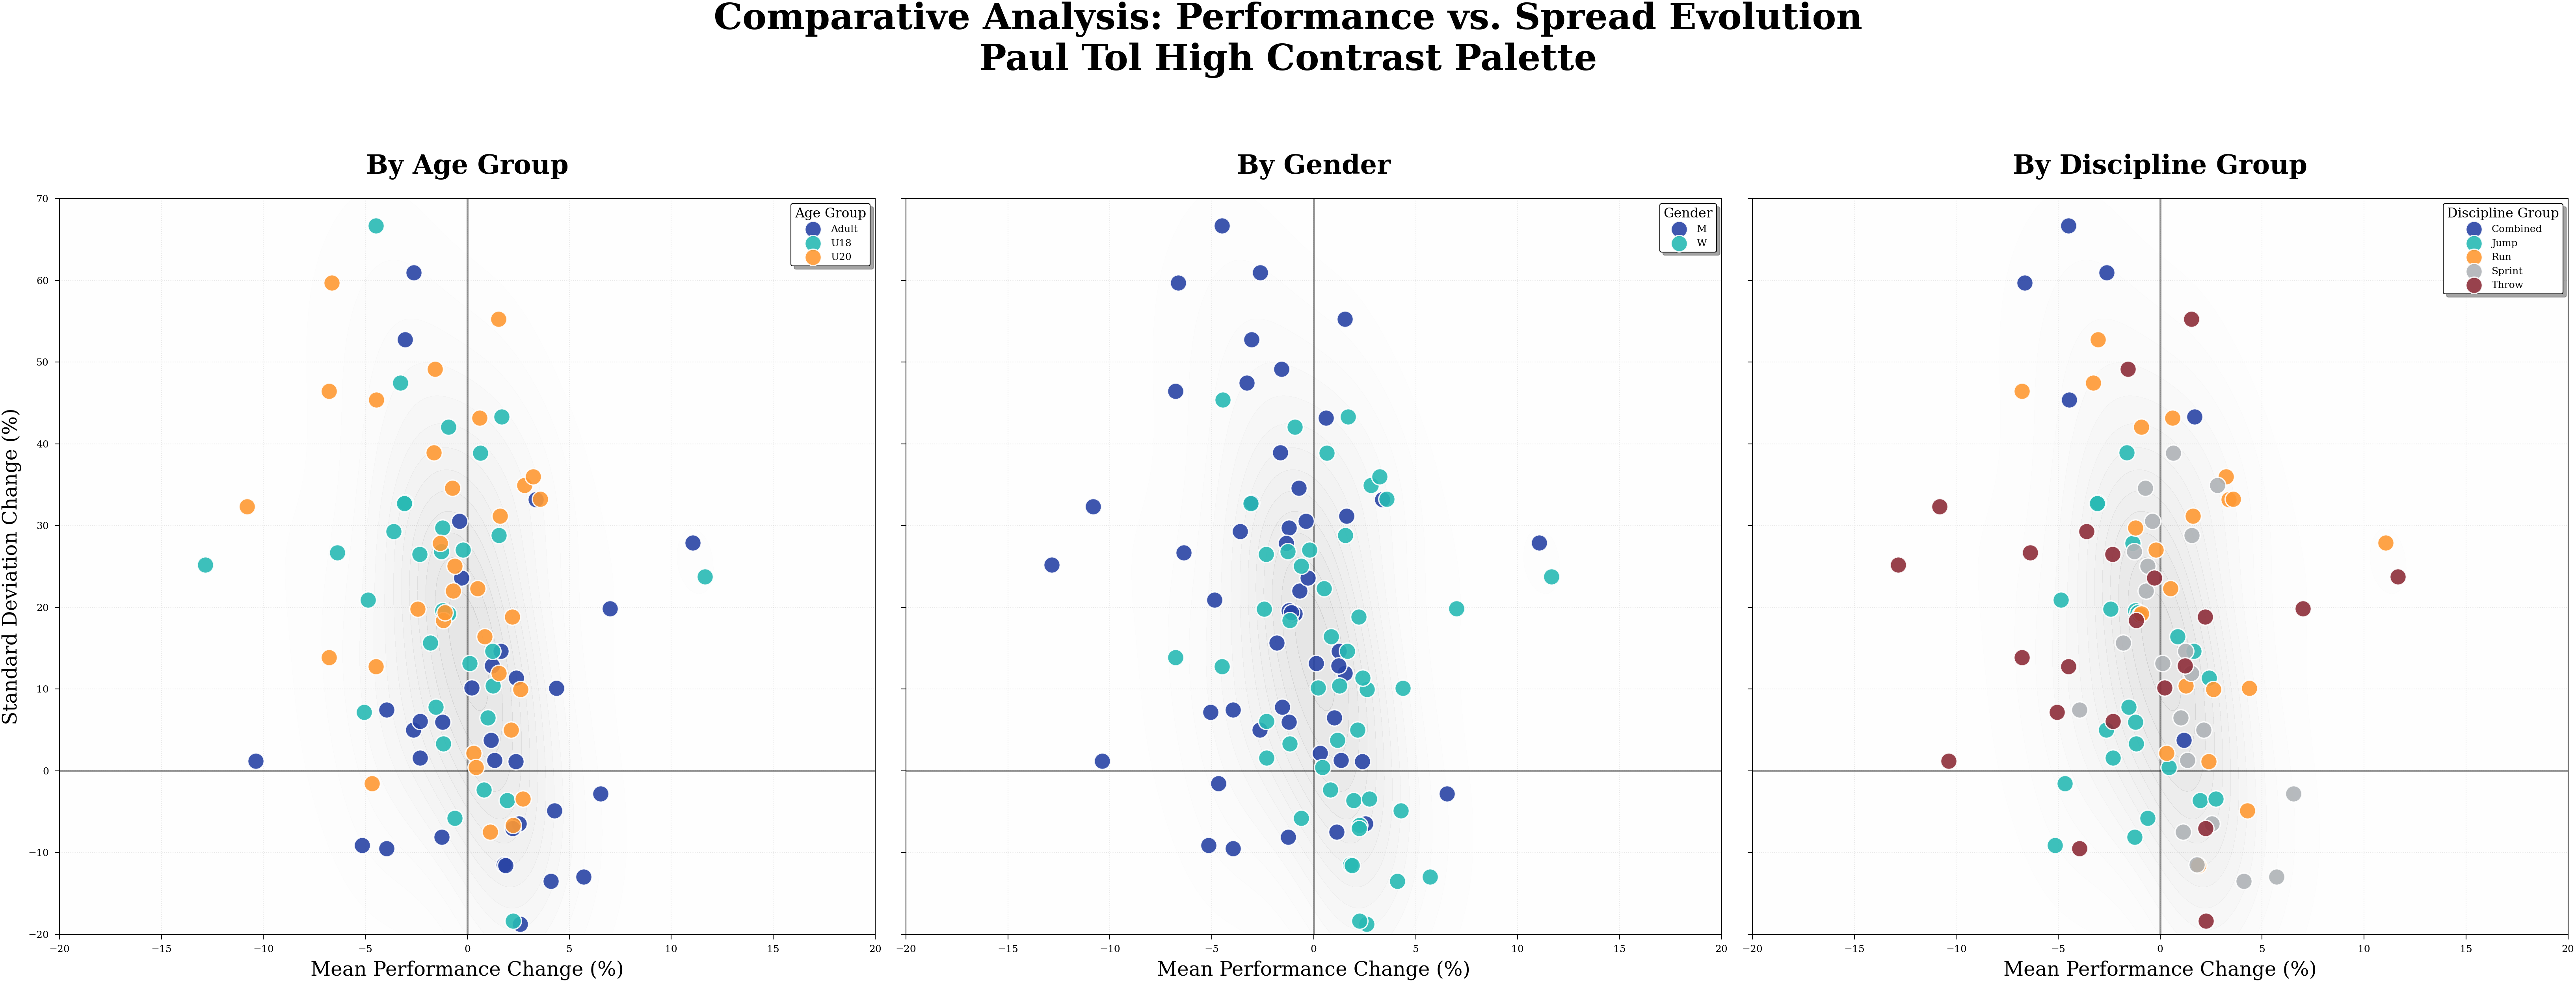

In [11]:
from tueplots import cycler
from tueplots.constants import markers
from tueplots.constants.color import palettes

from scipy.stats import gaussian_kde

# 1. Apply your specific color palette
# Assuming 'palettes' is already imported in your environment
plt.rcParams.update(cycler.cycler(color=palettes.pn[:5]))

# 2. Setup & Data Cleaning
clean_data = per_subgroup.dropna(subset=["Mean_Diff_%", "STD_Diff_%"]).copy()

clean_data['disziplingruppe'] = clean_data['disziplin'].map(mapping_dict)

# 3. Manual Limits & Global KDE Calculation
x_min, x_max = -20, 20
y_min, y_max = -20, 70

x_vals = clean_data["Mean_Diff_%"].values
y_vals = clean_data["STD_Diff_%"].values
k = gaussian_kde(np.vstack([x_vals, y_vals]))
xi, yi = np.mgrid[x_min:x_max:200j, y_min:y_max:200j]
zi = k(np.vstack([xi.flatten(), yi.flatten()]))

# 4. Create Subplots
fig, axes = plt.subplots(1, 3, figsize=(22, 8), sharey=True, sharex=True)
categories = [
    ('altersklasse', 'Age Group'),
    ('geschlecht', 'Gender'),
    ('disziplingruppe', 'Discipline Group')
]

for i, (col, title) in enumerate(categories):
    ax = axes[i]
    
    # Background Density Contour
    ax.contourf(xi, yi, zi.reshape(xi.shape), levels=15, cmap="Greys", alpha=0.1, zorder=1)
    
    # Dynamic Scatter using the updated cycler
    # We don't specify 'c=color'; Matplotlib will cycle through Paul Tol colors automatically
    unique_labels = sorted(clean_data[col].dropna().unique())
    
    for label in unique_labels:
        mask = clean_data[col] == label
        if mask.any():
            ax.scatter(
                clean_data.loc[mask, "Mean_Diff_%"], 
                clean_data.loc[mask, "STD_Diff_%"], 
                label=label, 
                s=100, 
                edgecolor='white',
                linewidth=0.8, 
                alpha=0.9, 
                zorder=3
            )
    
    # Reference Lines
    ax.axvline(0, color='black', linestyle='-', alpha=0.4, linewidth=1.2, zorder=2)
    ax.axhline(0, color='black', linestyle='-', alpha=0.4, linewidth=1.2, zorder=2)
    
    # Limits & Styling
    ax.set_xlim(x_min, x_max)
    ax.set_ylim(y_min, y_max)
    ax.set_title(f"By {title}", fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel("Mean Performance Change (%)", fontsize=12)
    if i == 0:
        ax.set_ylabel("Standard Deviation Change (%)", fontsize=12)
    
    ax.legend(title=title, loc='upper right', frameon=True, shadow=True)
    ax.grid(True, linestyle=':', alpha=0.3, zorder=0)

plt.suptitle("Comparative Analysis: Performance vs. Spread Evolution\nPaul Tol High Contrast Palette", 
             fontsize=22, fontweight='bold', y=1.05)

plt.tight_layout()
plt.show()

In [12]:
def print_final_table(title, df, group_col_names):
    """
    Prints stats tables. 
    group_col_names can be a string (e.g., "altersklasse") 
    or a list (e.g., ["geschlecht", "altersklasse"])
    """
    stats_cols = ["Mean_Diff_%", "P_Val_Mean", "Cohen_d", "STD_Diff_%", "P_Val_STD", "Interpretation"]
    
    # 1. Create copy to avoid modifying original data
    printable_df = df.copy()

    # 2. Handle Indexing for Multi-column or Single-column names
    # Ensure group_col_names is a list for consistency
    if isinstance(group_col_names, str):
        group_col_names = [group_col_names]
        
    # Set the index if the columns exist
    if all(col in printable_df.columns for col in group_col_names):
        printable_df = printable_df.set_index(group_col_names)

    # 3. Print
    print(f"\n{'='*25} {title.upper()} {'='*25}")
    # Only print columns that actually exist
    available_cols = [c for c in stats_cols if c in printable_df.columns]
    print(printable_df[available_cols].to_string())
    print("-" * 95)

# --- EXECUTION ---

# 1. Standard Single-Group Tables
print_final_table("Global", res_global, "Group")
print_final_table("Age Groups", results_age, "altersklasse")
print_final_table("Gender", results_gender, "geschlecht")
print_final_table("Discipline Groups", results_disc_group, "disziplingruppe")

# 2. Combined Gender + Age Table
# This will show indices like (M, Adult), (M, U18), etc.
print_final_table("Gender & Age Combined", results_age_gender, ["geschlecht", "altersklasse"])
print_final_table("All Subgroups", per_subgroup, ["disziplin","geschlecht", "altersklasse"])



========================= GLOBAL =========================
        Mean_Diff_%  P_Val_Mean  Cohen_d  STD_Diff_%  P_Val_STD Interpretation
Group                                                                         
Global         0.01      0.9384    0.001       11.83        0.0     Negligible
-----------------------------------------------------------------------------------------------

========================= AGE GROUPS =========================
              Mean_Diff_%  P_Val_Mean  Cohen_d  STD_Diff_%  P_Val_STD Interpretation
altersklasse                                                                        
Adult                0.91      0.0000    0.101       10.90     0.0000     Negligible
U18                 -0.24      0.3062   -0.021        3.34     0.0264     Negligible
U20                 -0.77      0.0009   -0.068       23.25     0.0000     Negligible
-----------------------------------------------------------------------------------------------

=====================

C:\Users\Mattis\AppData\Local\Temp\ipykernel_24936\1734350890.py:54: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


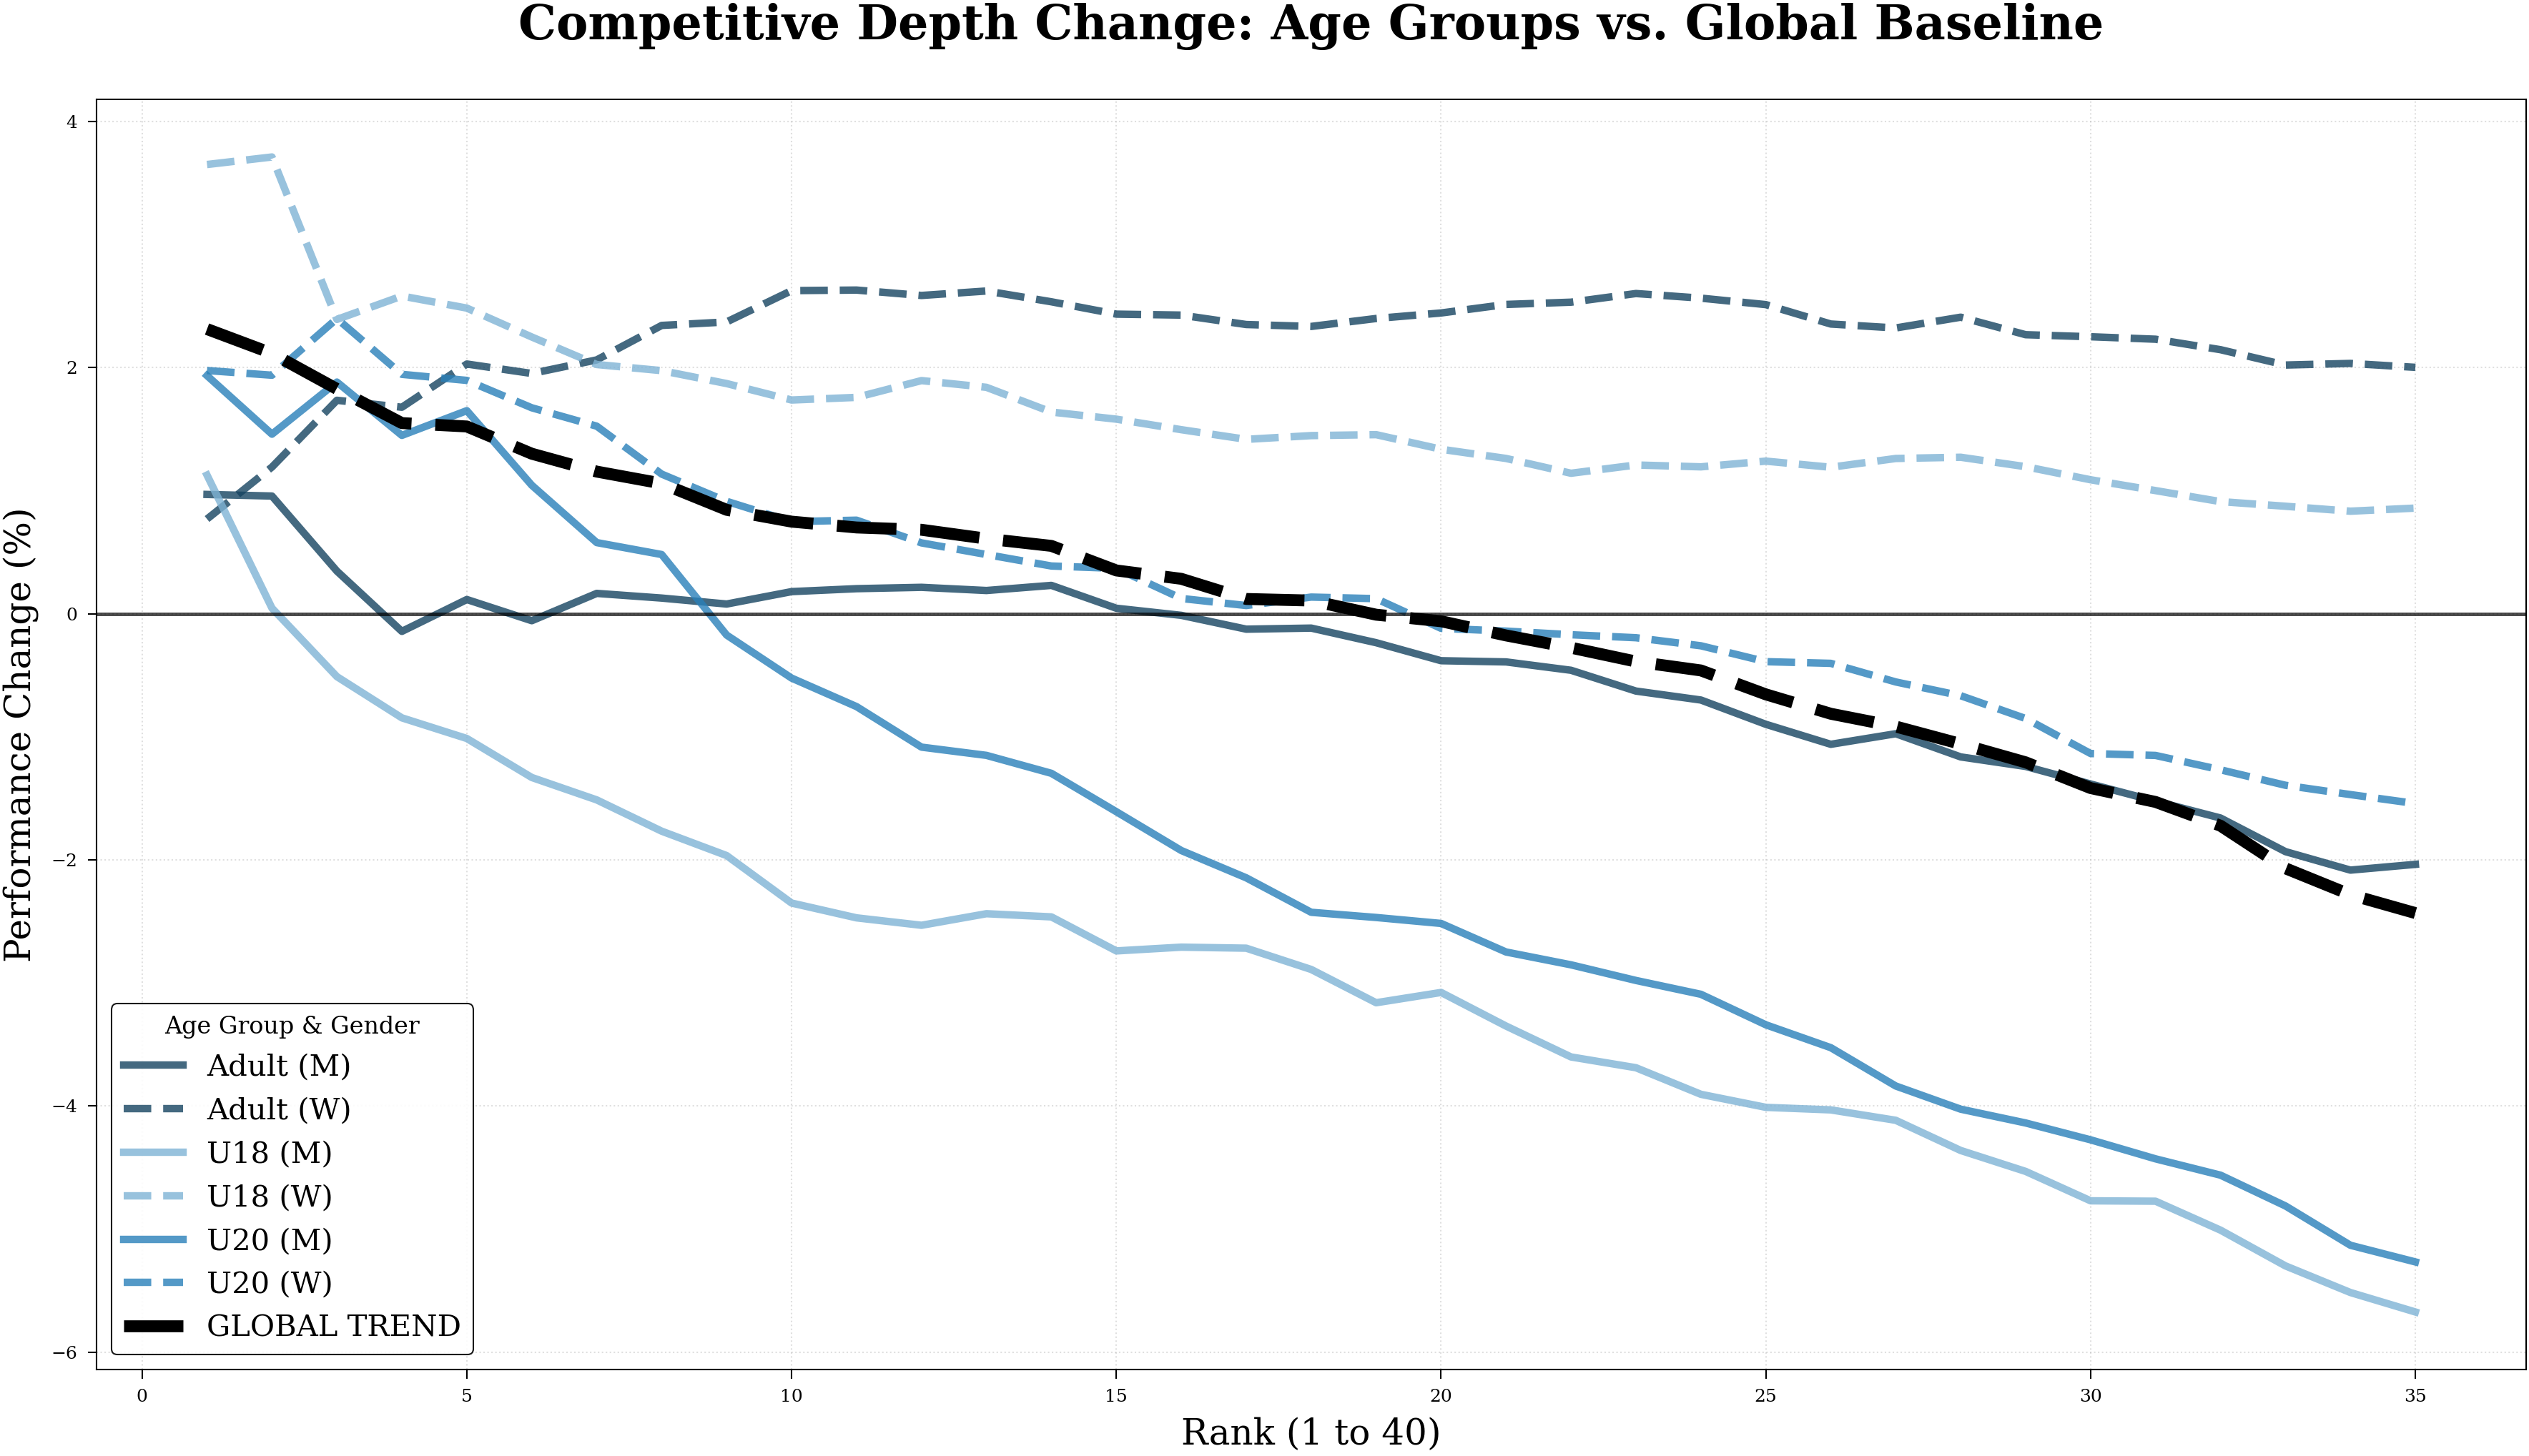

In [13]:

# 1. Setup the Plot
plt.figure(figsize=(12, 7))
ax = plt.gca()

# 2. Plot Age & Gender specific trends (Matplotlib Loop)
age_colors = {"U18": "#7fb3d5", "U20": "#2980b9", "Adult": "#154360"}
gender_styles = {"M": "-", "W": "--"}  # Solid for Men, Dashed for Women

for (age, gender), group_df in results_ranks_age.groupby(["altersklasse", "geschlecht"]):
    color = age_colors.get(age, "grey")
    linestyle = gender_styles.get(gender, "-")
    label = f"{age} ({gender})"
    
    plt.plot(
        group_df["rank"], 
        group_df["mean_diff_perc"], 
        color=color, 
        linestyle=linestyle, 
        linewidth=2.5, 
        alpha=0.8, 
        label=label
    )

# 3. Global Trend (Dashed Black Line)
plt.plot(
    results_ranks_all["rank"], 
    results_ranks_all["mean_diff_perc"], 
    color="black", 
    linewidth=4, 
    linestyle=(0, (5, 2)), 
    label="GLOBAL TREND", 
    zorder=5
)

# 4. Formatting and Styling
plt.axhline(0, color='black', linestyle='-', linewidth=1.2, alpha=0.7)
plt.title("Competitive Depth Change: Age Groups vs. Global Baseline", fontsize=16, pad=20, fontweight='bold')
plt.ylabel("Performance Change (%)", fontsize=12)
plt.xlabel("Rank (1 to 40)", fontsize=12)
plt.grid(True, which='both', linestyle=':', alpha=0.4)

# 5. LEGEND ON BOTTOM LEFT
# loc='lower left' places the corner of the legend at the bottom left
# framealpha=0.9 ensures it is slightly opaque to hide lines behind it
plt.legend(
    title="Age Group & Gender", 
    loc='lower left', 
    fontsize=10, 
    frameon=True, 
    facecolor='white', 
    framealpha=0.9
)

plt.tight_layout()
plt.savefig("rank_depth_bottom_legend.png", dpi=300)
plt.show()

In [14]:
import pandas as pd

# Define the baseline
baseline_start = (2001, 2004)
comparison_windows = [(2005, 2008), (2009, 2012), (2013, 2016), (2017, 2020), (2021, 2024)]

gender_results = []

for start, end in comparison_windows:
    # Group by gender this time
    res = hp.calculate_enhanced_stats(
        data_filtered, 
        group_cols=["geschlecht"], 
        start_period=baseline_start, 
        end_period=(start, end)
    )
    res['Comparison_Period'] = f"{start}-{end}"
    gender_results.append(res)

# Combine and organize
gender_evolution = pd.concat(gender_results, ignore_index=True)
cols = ["Comparison_Period", "Mean_Diff_%", "P_Val_Mean", "Cohen_d", "STD_Diff_%", "P_Val_STD", "Interpretation"]

# Print Men
print("========================= MEN: EVOLUTION vs. 2001-04 =========================")
print(gender_evolution[gender_evolution['geschlecht'] == 'M'][cols].to_string(index=False))

# Print Women
print("\n========================= WOMEN: EVOLUTION vs. 2001-04 =========================")
print(gender_evolution[gender_evolution['geschlecht'] == 'W'][cols].to_string(index=False))

========================= MEN: EVOLUTION vs. 2001-04 =========================
Comparison_Period  Mean_Diff_%  P_Val_Mean  Cohen_d  STD_Diff_%  P_Val_STD Interpretation
        2005-2008         0.34      0.0634    0.031       -2.02     0.0140     Negligible
        2009-2012         0.08      0.6724    0.007        5.12     0.0014     Negligible
        2013-2016        -0.21      0.2679   -0.019        9.45     0.0000     Negligible
        2017-2020        -1.61      0.0000   -0.135       15.67     0.0000     Negligible
        2021-2024        -1.48      0.0000   -0.121       19.89     0.0000     Negligible

========================= WOMEN: EVOLUTION vs. 2001-04 =========================
Comparison_Period  Mean_Diff_%  P_Val_Mean  Cohen_d  STD_Diff_%  P_Val_STD Interpretation
        2005-2008         0.04      0.8504    0.003       -0.47     0.3150     Negligible
        2009-2012         0.48      0.0222    0.039        0.35     0.0846     Negligible
        2013-2016         1.2

Calculating yearly stats vs. baseline...


C:\Users\Mattis\AppData\Local\Temp\ipykernel_24936\426308059.py:52: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


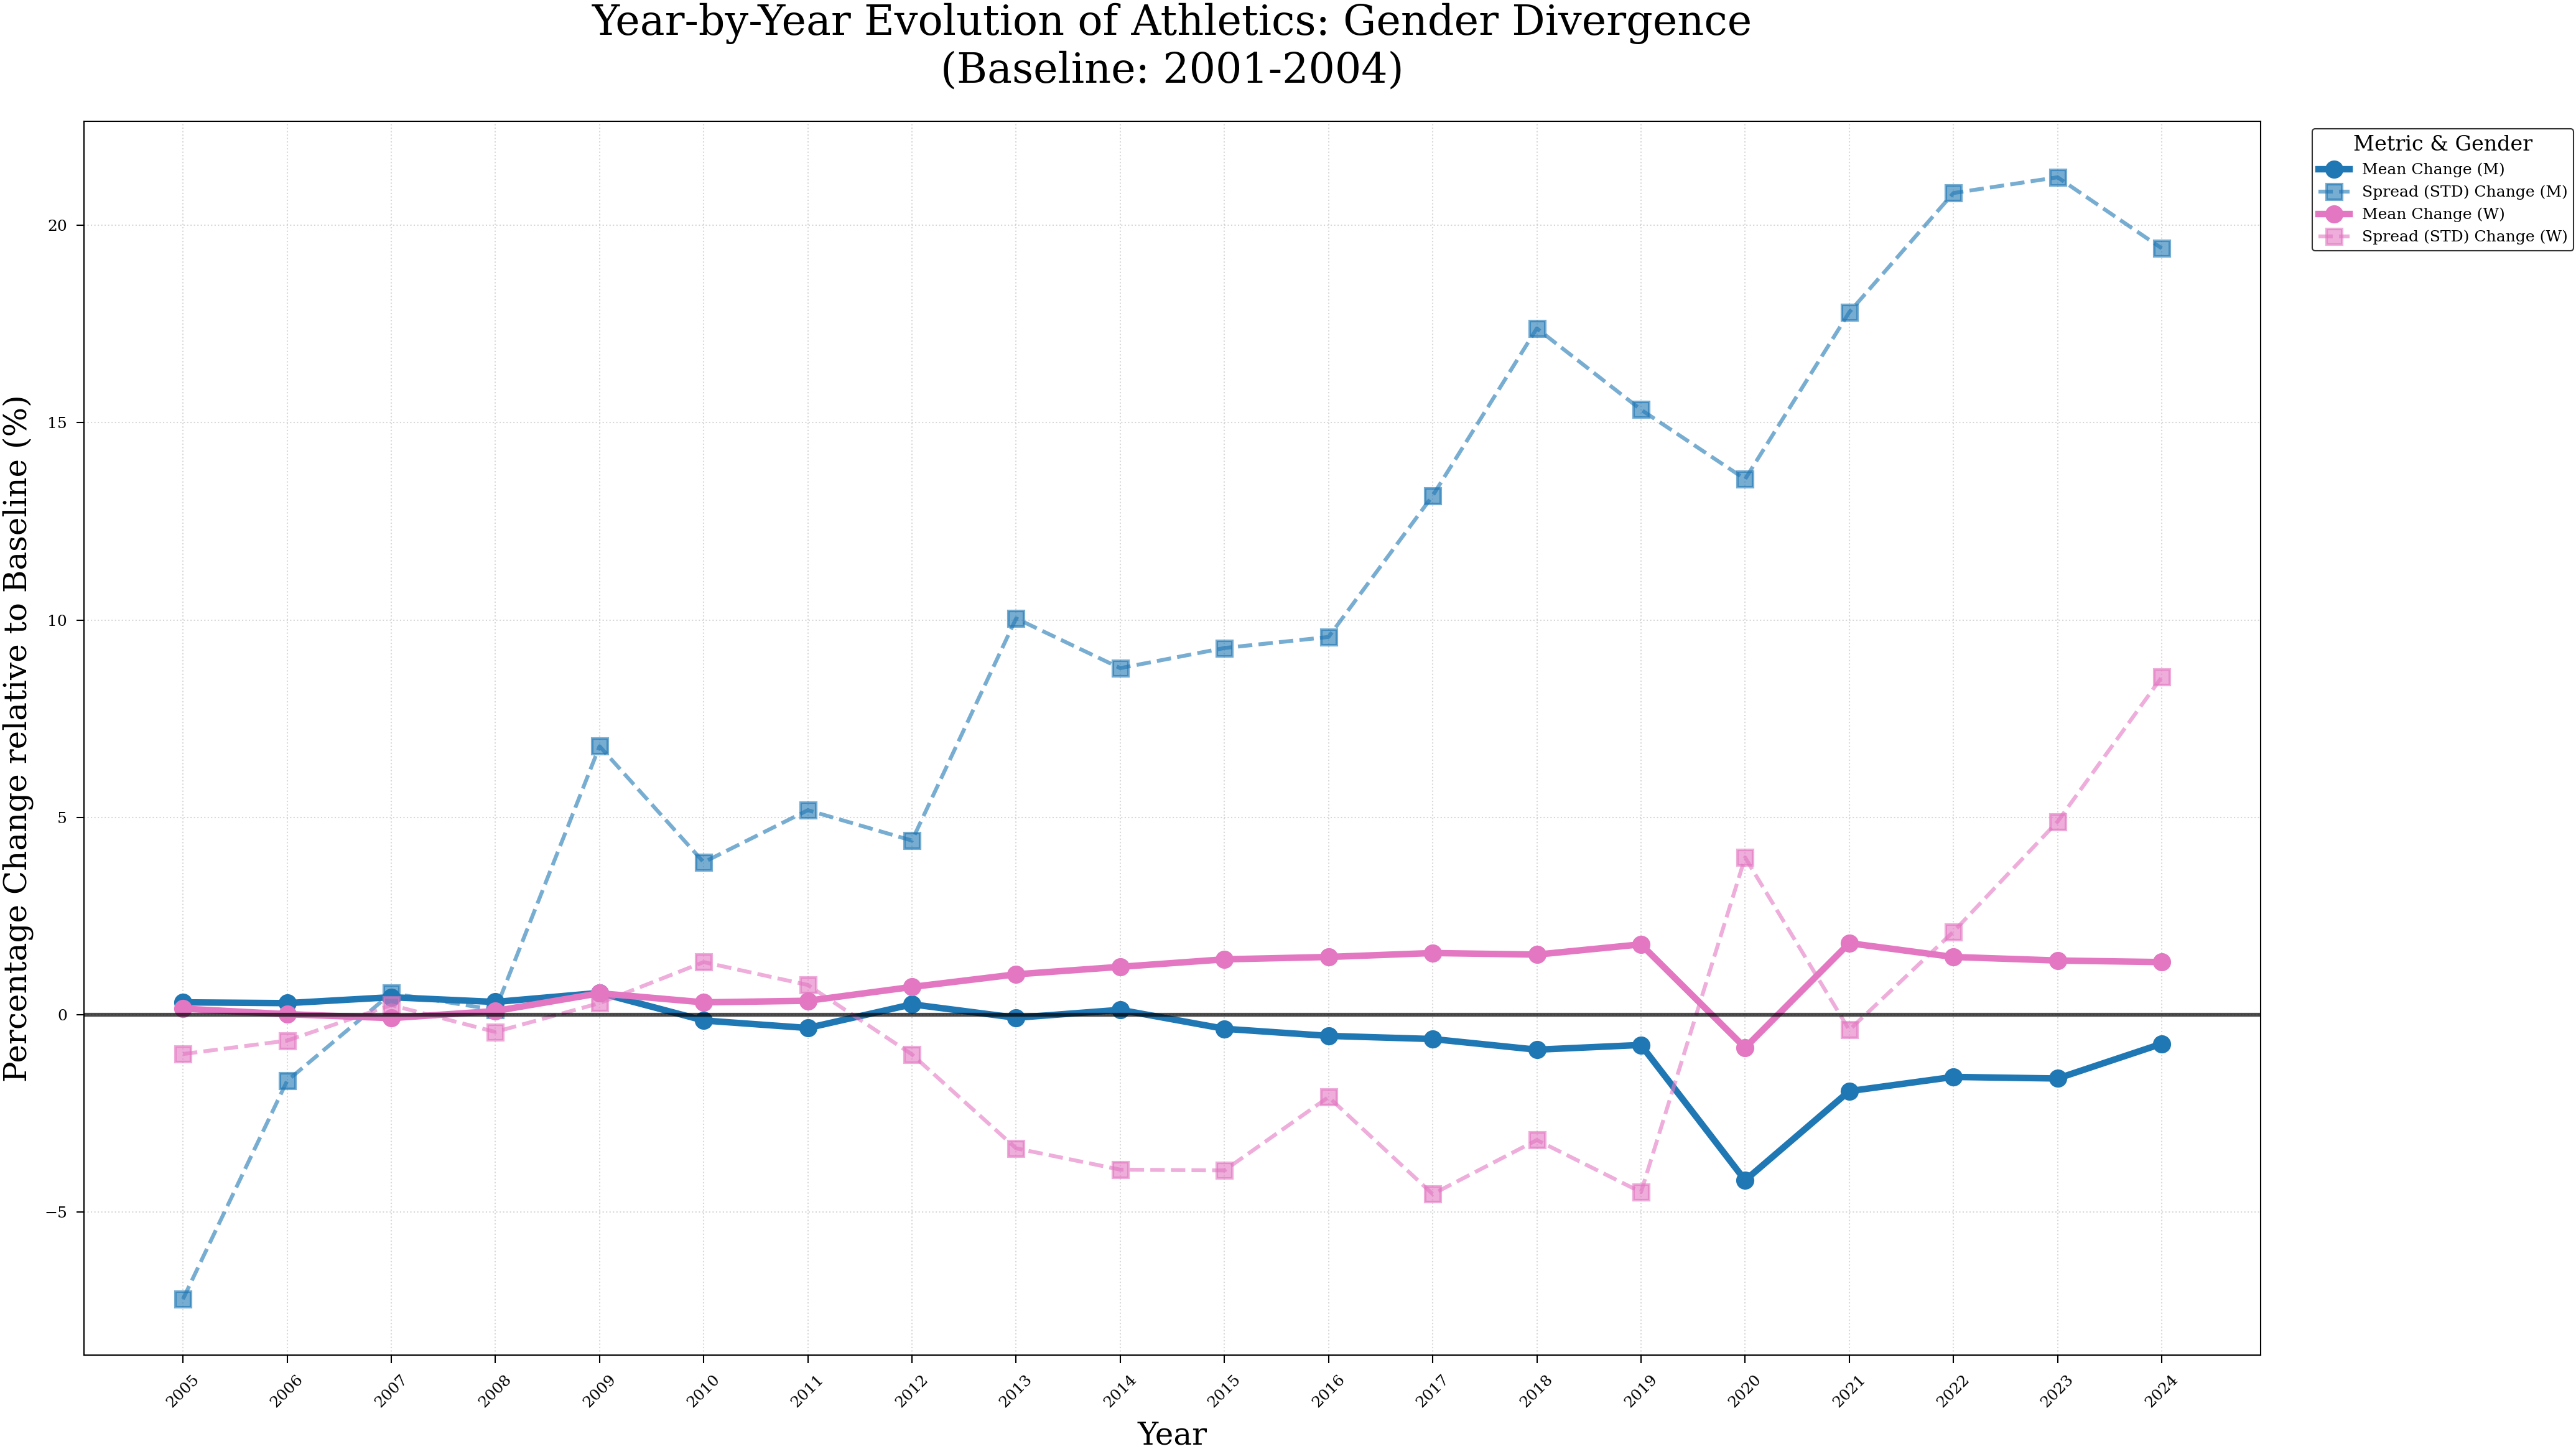


MOST RECENT YEARLY TRENDS (2020-2024):
 Year geschlecht  Mean_Diff_%  P_Val_Mean  STD_Diff_%  P_Val_STD
 2020          M        -4.20      0.0000       13.57     0.0000
 2020          W        -0.84      0.0131        3.98     0.0208
 2021          M        -1.94      0.0000       17.80     0.0000
 2021          W         1.81      0.0000       -0.39     0.6753
 2022          M        -1.58      0.0000       20.82     0.0000
 2022          W         1.46      0.0000        2.10     0.0462
 2023          M        -1.62      0.0000       21.22     0.0000
 2023          W         1.37      0.0000        4.89     0.0003
 2024          M        -0.74      0.0312       19.42     0.0000
 2024          W         1.33      0.0001        8.55     0.0000


In [15]:

# --- 1. SETUP PERIODS ---
baseline_start = (2001, 2004)
years_to_compare = range(2005, 2025)  # Analyzes 2005, 2006, ..., 2024
yearly_results = []

# --- 2. EXECUTE YEARLY LOOP ---
print("Calculating yearly stats vs. baseline...")
for year in years_to_compare:
    # We compare the fixed baseline to each specific year
    res = hp.calculate_enhanced_stats(
        data_filtered, 
        group_cols=["geschlecht"], 
        start_period=baseline_start, 
        end_period=(year, year)
    )
    res['Year'] = year
    yearly_results.append(res)

# Combine into a single DataFrame
evolution_yearly = pd.concat(yearly_results, ignore_index=True)

# --- 3. PLOT THE YEARLY TREND ---
plt.figure(figsize=(14, 8))

# Define colors and styles
colors = {'M': '#1f77b4', 'W': '#e377c2'}  # Blue for Men, Pink for Women

for gender in ['M', 'W']:
    subset = evolution_yearly[evolution_yearly['geschlecht'] == gender]
    
    # Plot Mean Change (Solid Line)
    plt.plot(subset["Year"], subset["Mean_Diff_%"], 
             marker='o', label=f"Mean Change ({gender})", 
             color=colors[gender], linewidth=2.5)
    
    # Plot STD Change (Dashed Line)
    plt.plot(subset["Year"], subset["STD_Diff_%"], 
             marker='s', linestyle='--', label=f"Spread (STD) Change ({gender})", 
             color=colors[gender], alpha=0.6, linewidth=1.5)

# --- 4. FORMATTING ---
plt.axhline(0, color='black', linewidth=1.5, alpha=0.7)
plt.title("Year-by-Year Evolution of Athletics: Gender Divergence\n(Baseline: 2001-2004)", fontsize=16, pad=15)
plt.ylabel("Percentage Change relative to Baseline (%)", fontsize=12)
plt.xlabel("Year", fontsize=12)
plt.xticks(years_to_compare, rotation=45)
plt.grid(True, which='both', linestyle=':', alpha=0.5)

# Legend positioning
plt.legend(title="Metric & Gender", bbox_to_anchor=(1.02, 1), loc='upper left')

plt.tight_layout()
plt.show()

# --- 5. OPTIONAL: SHOW SIGNIFICANCE TABLE ---
# Filtering for the most recent 5 years to see the current status
print("\nMOST RECENT YEARLY TRENDS (2020-2024):")
print(evolution_yearly[evolution_yearly['Year'] >= 2020][["Year", "geschlecht", "Mean_Diff_%", "P_Val_Mean", "STD_Diff_%", "P_Val_STD"]].to_string(index=False))

C:\Users\Mattis\AppData\Local\Temp\ipykernel_24936\3496023166.py:55: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


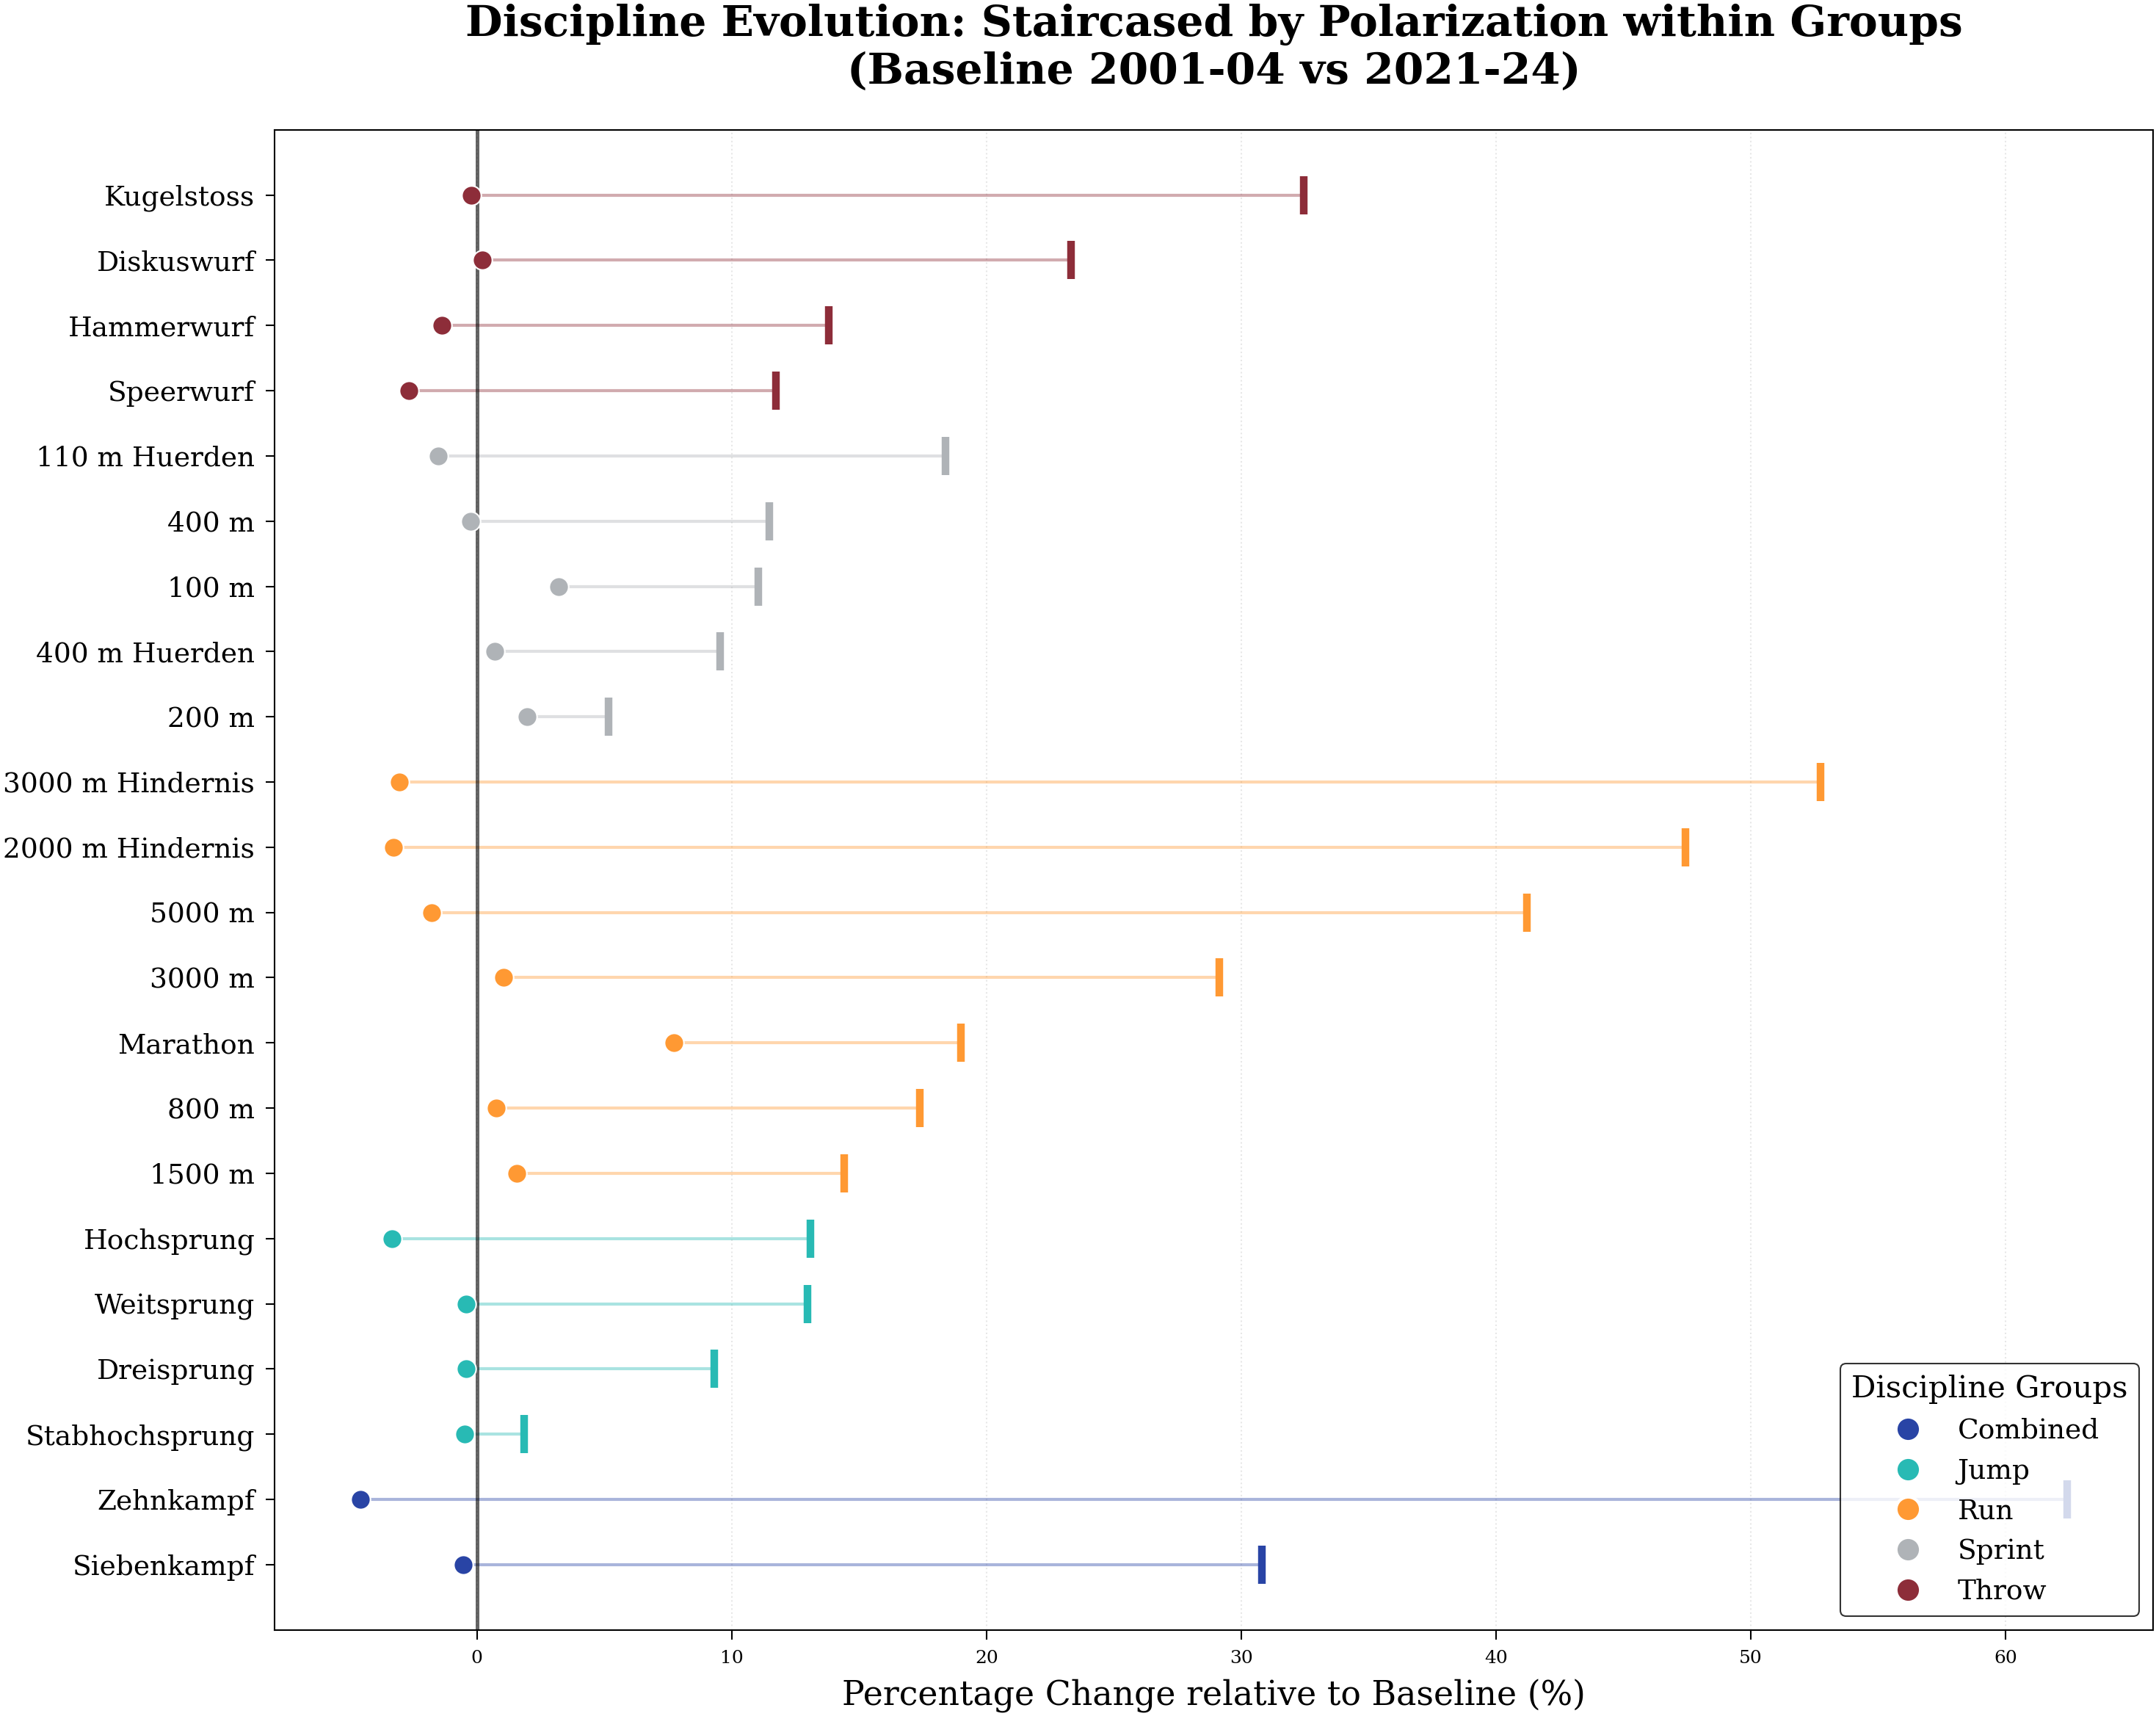

In [23]:
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

# 1. Prepare Data
# Aggregate mean values per discipline
detailed_data = clean_data.groupby(['disziplingruppe', 'disziplin'])[['Mean_Diff_%', 'STD_Diff_%']].mean().reset_index()

# THE FIX: Sort by Group alphabetically, then by STD strength within that group
# This creates the "Staircase" effect inside every color block
detailed_data = detailed_data.sort_values(['disziplingruppe', 'STD_Diff_%'], ascending=[True, True])

# 2. Setup Plot and Palette
# Height reduced (8 instead of 14) and margins tightened to bring rows closer
plt.figure(figsize=(10, 8)) 
plt.rcParams.update(cycler.cycler(color=palettes.pn[:5]))
colors_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']

unique_groups = sorted(detailed_data['disziplingruppe'].unique())
group_color_map = {group: colors_cycle[i % len(colors_cycle)] for i, group in enumerate(unique_groups)}

# 3. Plotting
for i, (idx, row) in enumerate(detailed_data.iterrows()):
    group_color = group_color_map[row['disziplingruppe']]
    
    # Draw the Gap Line (The 'Lollipop' stick)
    plt.hlines(y=i, xmin=row['Mean_Diff_%'], xmax=row['STD_Diff_%'], 
               color=group_color, alpha=0.4, linewidth=1.0)
    
    # Plot Mean (The Dot)
    plt.scatter(row['Mean_Diff_%'], i, color=group_color, s=40, 
                edgecolor='white', linewidth=0.5, zorder=3)
    
    # Plot STD (The Bar / Polarization Strength)
    plt.scatter(row['STD_Diff_%'], i, color=group_color, s=150, 
                marker='|', linewidth=2.5, zorder=3)

# 4. Final Formatting
plt.yticks(range(len(detailed_data)), detailed_data['disziplin'], fontsize=9)
plt.axvline(0, color='black', linestyle='-', alpha=0.6, linewidth=1.2)

# Bring disciplines "near together" by setting tight y-limits
plt.ylim(-1, len(detailed_data))

# Create custom legend
legend_elements = [Line2D([0], [0], marker='o', color='w', label=g,
                          markerfacecolor=c, markersize=8) for g, c in group_color_map.items()]
plt.legend(handles=legend_elements, title="Discipline Groups", loc='lower right', 
           frameon=True, fontsize=9, title_fontsize=10)

plt.title("Discipline Evolution: Staircased by Polarization within Groups\n(Baseline 2001-04 vs 2021-24)", 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel("Percentage Change relative to Baseline (%)", fontsize=11)
plt.grid(axis='x', linestyle=':', alpha=0.3)

plt.tight_layout()
plt.show()